<center><img src="https://github.com/magnitopic/saturdaysai-ml/blob/main/img/logo_saturdays_madrid.jpg?raw=1" alt="Logo AI Saturdays Madrid" title="Logo AI Saturdays Madrid" width="150"/></center>

# Week 1 Challenge - Bank Classifier

Bank marketing campaigns depend on customer data. The volume of data handled by banks is so large that it is virtually impossible for a data analyst to extract maximum value from it in a way that is truly effective in the decision-making process.

This is where machine learning models are helping to dramatically increase campaign performance by uncovering patterns in the data that would otherwise go unnoticed by analysts.

## Dataset

The dataset we will work with in this challenge is related to a direct marketing campaign of a Portuguese banking institution. During the campaign, which was based on phone calls, it was often necessary to contact the same customer **more than once** to offer them a term deposit subscription.

Our goal is to predict whether the customer will subscribe to a **term deposit** by analysing and preprocessing the data. These data will then be used to build a classification model using the k-NN algorithm.

The input variables (features) are:
* `age` - Age of the customer.
* `job` - Type of job held by the customer.
* `marital` - Marital status.
* `education` - Education level.
* `default` - Whether the customer has credit in default.
* `balance` - Customer's account balance.
* `housing` - Whether the customer has a housing loan.
* `loan` - Whether the customer has a personal loan.
* `contact` - Type of communication used to contact the customer.
* `day` - Day of the month of the last contact.
* `month` - Month of the year of the last contact.
* `duration` - Duration of the last contact in seconds. **Important!** This attribute strongly affects the output variable (e.g. if `duration=0` then `y='no'`). However, the duration is not known before a call is made. Also, after the call ends, `y` is obviously known. Therefore, this input variable should only be included for benchmarking purposes and should be discarded when building a realistic predictive model, as it would constitute what is known as _data leakage_.
* `campaign` - Number of contacts performed during this campaign for this client.
* `pdays` - Number of days that have passed since the client was last contacted from a previous campaign; `pdays=-1` means the client was never previously contacted.
* `previous` - Number of contacts performed before this campaign for this client.
* `poutcome` - Outcome of the previous marketing campaign.

The variable we want to predict is `y`, which indicates whether the client ultimately subscribed to a term deposit.

More information about this dataset can be found at [UCI Machine Learning Repository - Bank Marketing Data Set](https://archive.ics.uci.edu/ml/datasets/bank+marketing).

## 1. Import Libraries

These are the libraries we will need to import to complete the _challenge_.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, classification_report,
                             roc_curve, roc_auc_score)

## 2. Load the Data

**Create a DataFrame called `data` from the CSV file containing the marketing campaign data. Watch out for the separator!**

In [ ]:
# Load the dataset from GitHub; the separator is ';' instead of the usual comma
data = pd.read_csv("bank.csv", sep=';')

## 3. General Dataset Exploration

### 3.1. First Rows

**Display the first 10 rows of the dataset.**

In [3]:
data.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


### 3.2. Dimensions

**Print the number of rows (records/observations) and columns (variables/features) in the dataset.**

In [4]:
rows, columns = data.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 45211 rows and 17 columns.


### 3.3. General Information

**Display the general information of the dataset.**

In [5]:
# Shows data types, number of non-null values and memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### 3.4. Unique Values per Column (Cardinality)

**Display the number of unique values in each column.**

In [6]:
# Cardinality helps identify which columns are candidates to be categorical
print(data.nunique().to_string())

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2


### 3.5. Null Values

**Check for the existence of null values in the dataset.**

In [7]:
nulls = data.isnull().sum()
print("Null values per column:")
print(nulls[nulls >= 0].to_string())
print(f"\nTotal null values in the dataset: {nulls.sum()}")

Null values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0

Total null values in the dataset: 0


> **Conclusion:** There are no null values in any column. However, some columns use the string `'unknown'` as a special placeholder for missing data — this will be handled during preprocessing.

### 3.6. Descriptive Statistics

**Display a basic statistical description of the dataset.**

In [8]:
# describe() analyses only numeric columns by default
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 3.7. Numerical and Categorical Variables

**According to their type, which input variables are categorical and which are numerical?**

In [9]:
# Separate columns by data type
numerical_cols   = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical variables   ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical variables ({len(categorical_cols)}): {categorical_cols}")

Numerical variables   (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical variables (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


### 3.8. Distribution of Categorical Variables

**Display the possible values of each categorical variable along with their absolute and relative frequencies.**

In [10]:
for col in categorical_cols:
    print(f"{'─'*40}")
    print(f"  Variable: {col.upper()}")
    print(f"{'─'*40}")
    absolute  = data[col].value_counts()
    relative  = data[col].value_counts(normalize=True)
    for cat in absolute.index:
        print(f"  {cat:<20} {absolute[cat]:>6}  ({relative[cat]:>5.1%})")
    print()

────────────────────────────────────────
  Variable: JOB
────────────────────────────────────────
  blue-collar            9732  (21.5%)
  management             9458  (20.9%)
  technician             7597  (16.8%)
  admin.                 5171  (11.4%)
  services               4154  ( 9.2%)
  retired                2264  ( 5.0%)
  self-employed          1579  ( 3.5%)
  entrepreneur           1487  ( 3.3%)
  unemployed             1303  ( 2.9%)
  housemaid              1240  ( 2.7%)
  student                 938  ( 2.1%)
  unknown                 288  ( 0.6%)

────────────────────────────────────────
  Variable: MARITAL
────────────────────────────────────────
  married               27214  (60.2%)
  single                12790  (28.3%)
  divorced               5207  (11.5%)

────────────────────────────────────────
  Variable: EDUCATION
────────────────────────────────────────
  secondary             23202  (51.3%)
  tertiary              13301  (29.4%)
  primary                6851  

## 4. Exploratory Analysis of the Target Variable

### 4.1. Working Copy

**The target variable is the one we want to predict. Before making any modifications to the dataset, we will create a working copy so the original remains unchanged. Create a new DataFrame called `bank_data` as a copy of the original.**

In [11]:
# deep=True (default) ensures that changes to bank_data
# do not affect the original 'data' DataFrame
bank_data = data.copy()
print(f"Copy created: {bank_data.shape[0]} rows × {bank_data.shape[1]} columns")

Copy created: 45211 rows × 17 columns


### 4.2. Rename the Target Variable

**Rename the target variable `y` to `deposit`.**

In [12]:
# Rename 'y' → 'deposit' to make the meaning explicit
bank_data = bank_data.rename(columns={'y': 'deposit'})

# Verify that the last column is now called 'deposit'
print("Dataset columns:", bank_data.columns.tolist())

Dataset columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


### 4.3. Numerical Encoding of the Target Variable

**Change the values of the `deposit` variable from `yes/no` to `1/0` respectively.**

In [13]:
# Map 'yes' → 1 and 'no' → 0
# If any other value existed, .map() would convert it to NaN, alerting us to the error
bank_data['deposit'] = bank_data['deposit'].map({'yes': 1, 'no': 0})

# Verification: value counts and resulting data type
print(bank_data['deposit'].value_counts().rename({0: 'No (0)', 1: 'Yes (1)'}).to_string())
print(f"\nData type: {bank_data['deposit'].dtype}")

deposit
No (0)     39922
Yes (1)     5289

Data type: int64


### 4.4. Visualisation of the Target Variable

**Visualise the target variable with a countplot. What conclusion do you draw?**

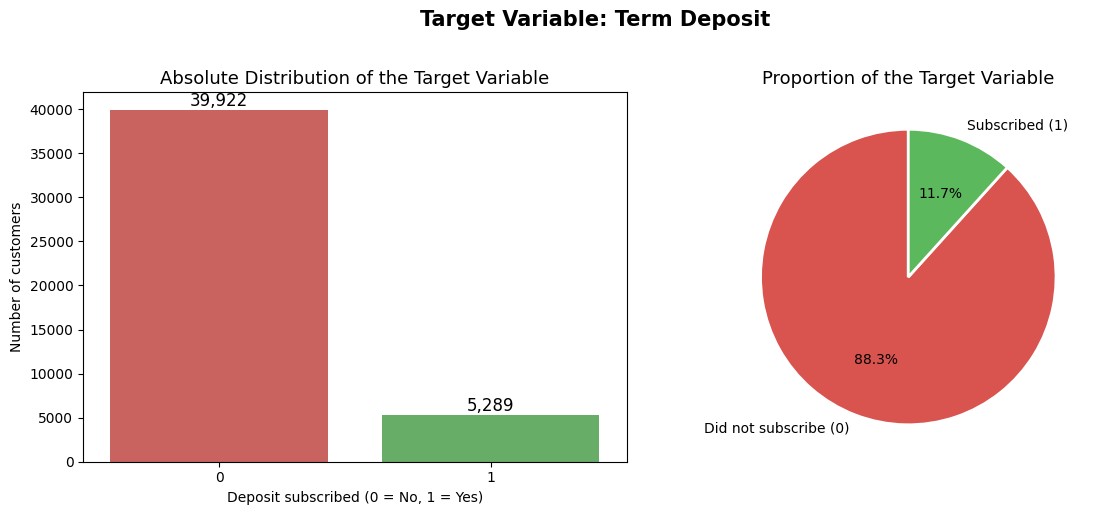

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left chart: absolute count ---
sns.countplot(x='deposit', data=bank_data, hue='deposit',
              palette=['#d9534f', '#5cb85c'], legend=False, ax=axes[0])
axes[0].set_title('Absolute Distribution of the Target Variable', fontsize=13)
axes[0].set_xlabel('Deposit subscribed (0 = No, 1 = Yes)')
axes[0].set_ylabel('Number of customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# --- Right chart: percentage ---
counts = bank_data['deposit'].value_counts()
axes[1].pie(counts, labels=['Did not subscribe (0)', 'Subscribed (1)'],
            autopct='%1.1f%%', colors=['#d9534f', '#5cb85c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of the Target Variable', fontsize=13)

plt.suptitle('Target Variable: Term Deposit', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Conclusion:** The dataset is **heavily imbalanced**: 88.3% of customers did **not** subscribe to the deposit, versus 11.7% who did. This imbalance is important to bear in mind during model evaluation, since a classifier that always predicts "No" would achieve 88% accuracy without learning anything useful. Therefore, alongside accuracy, we will use complementary metrics such as the ROC curve and the classification report.

## 5. Exploratory Analysis of the Predictor Variables

### 5.1. Age Distribution

**Show the age distribution of customers. Use any visualisation type you prefer.**

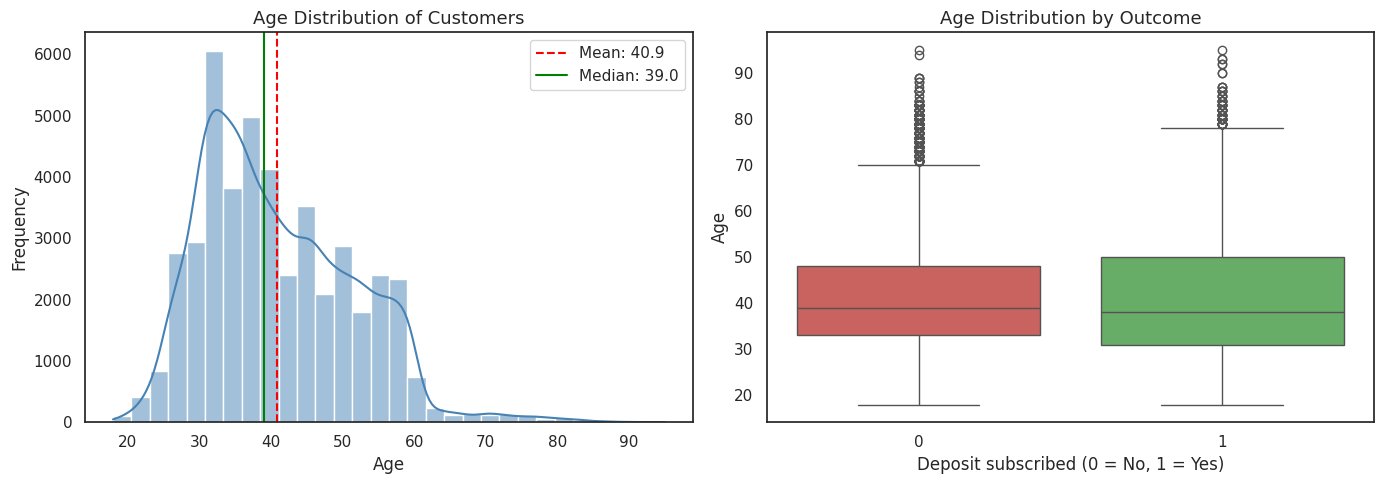

In [15]:
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram with KDE ---
sns.histplot(data=bank_data, x='age', kde=True, color='steelblue', bins=30, ax=axes[0])
axes[0].axvline(bank_data['age'].mean(),   color='red',   linestyle='--',
                label=f"Mean: {bank_data['age'].mean():.1f}")
axes[0].axvline(bank_data['age'].median(), color='green', linestyle='-',
                label=f"Median: {bank_data['age'].median():.1f}")
axes[0].set_title('Age Distribution of Customers', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Boxplot by deposit outcome ---
sns.boxplot(data=bank_data, x='deposit', y='age', hue='deposit',
            palette={0: '#d9534f', 1: '#5cb85c'}, legend=False, ax=axes[1])
axes[1].set_title('Age Distribution by Outcome', fontsize=13)
axes[1].set_xlabel('Deposit subscribed (0 = No, 1 = Yes)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

> **Conclusions:** The age distribution is right-skewed, with most customers between 25 and 60 years old. The mean (~41 years) and median (~39 years) are close together. The boxplot reveals that customers who **did** subscribe (1) show a slightly wider age distribution, with greater presence of both young customers and retirees.

### 5.2. Categorical Variables vs. Target Variable

**Create a barplot for each categorical predictor variable in the dataset as a function of the target variable.**

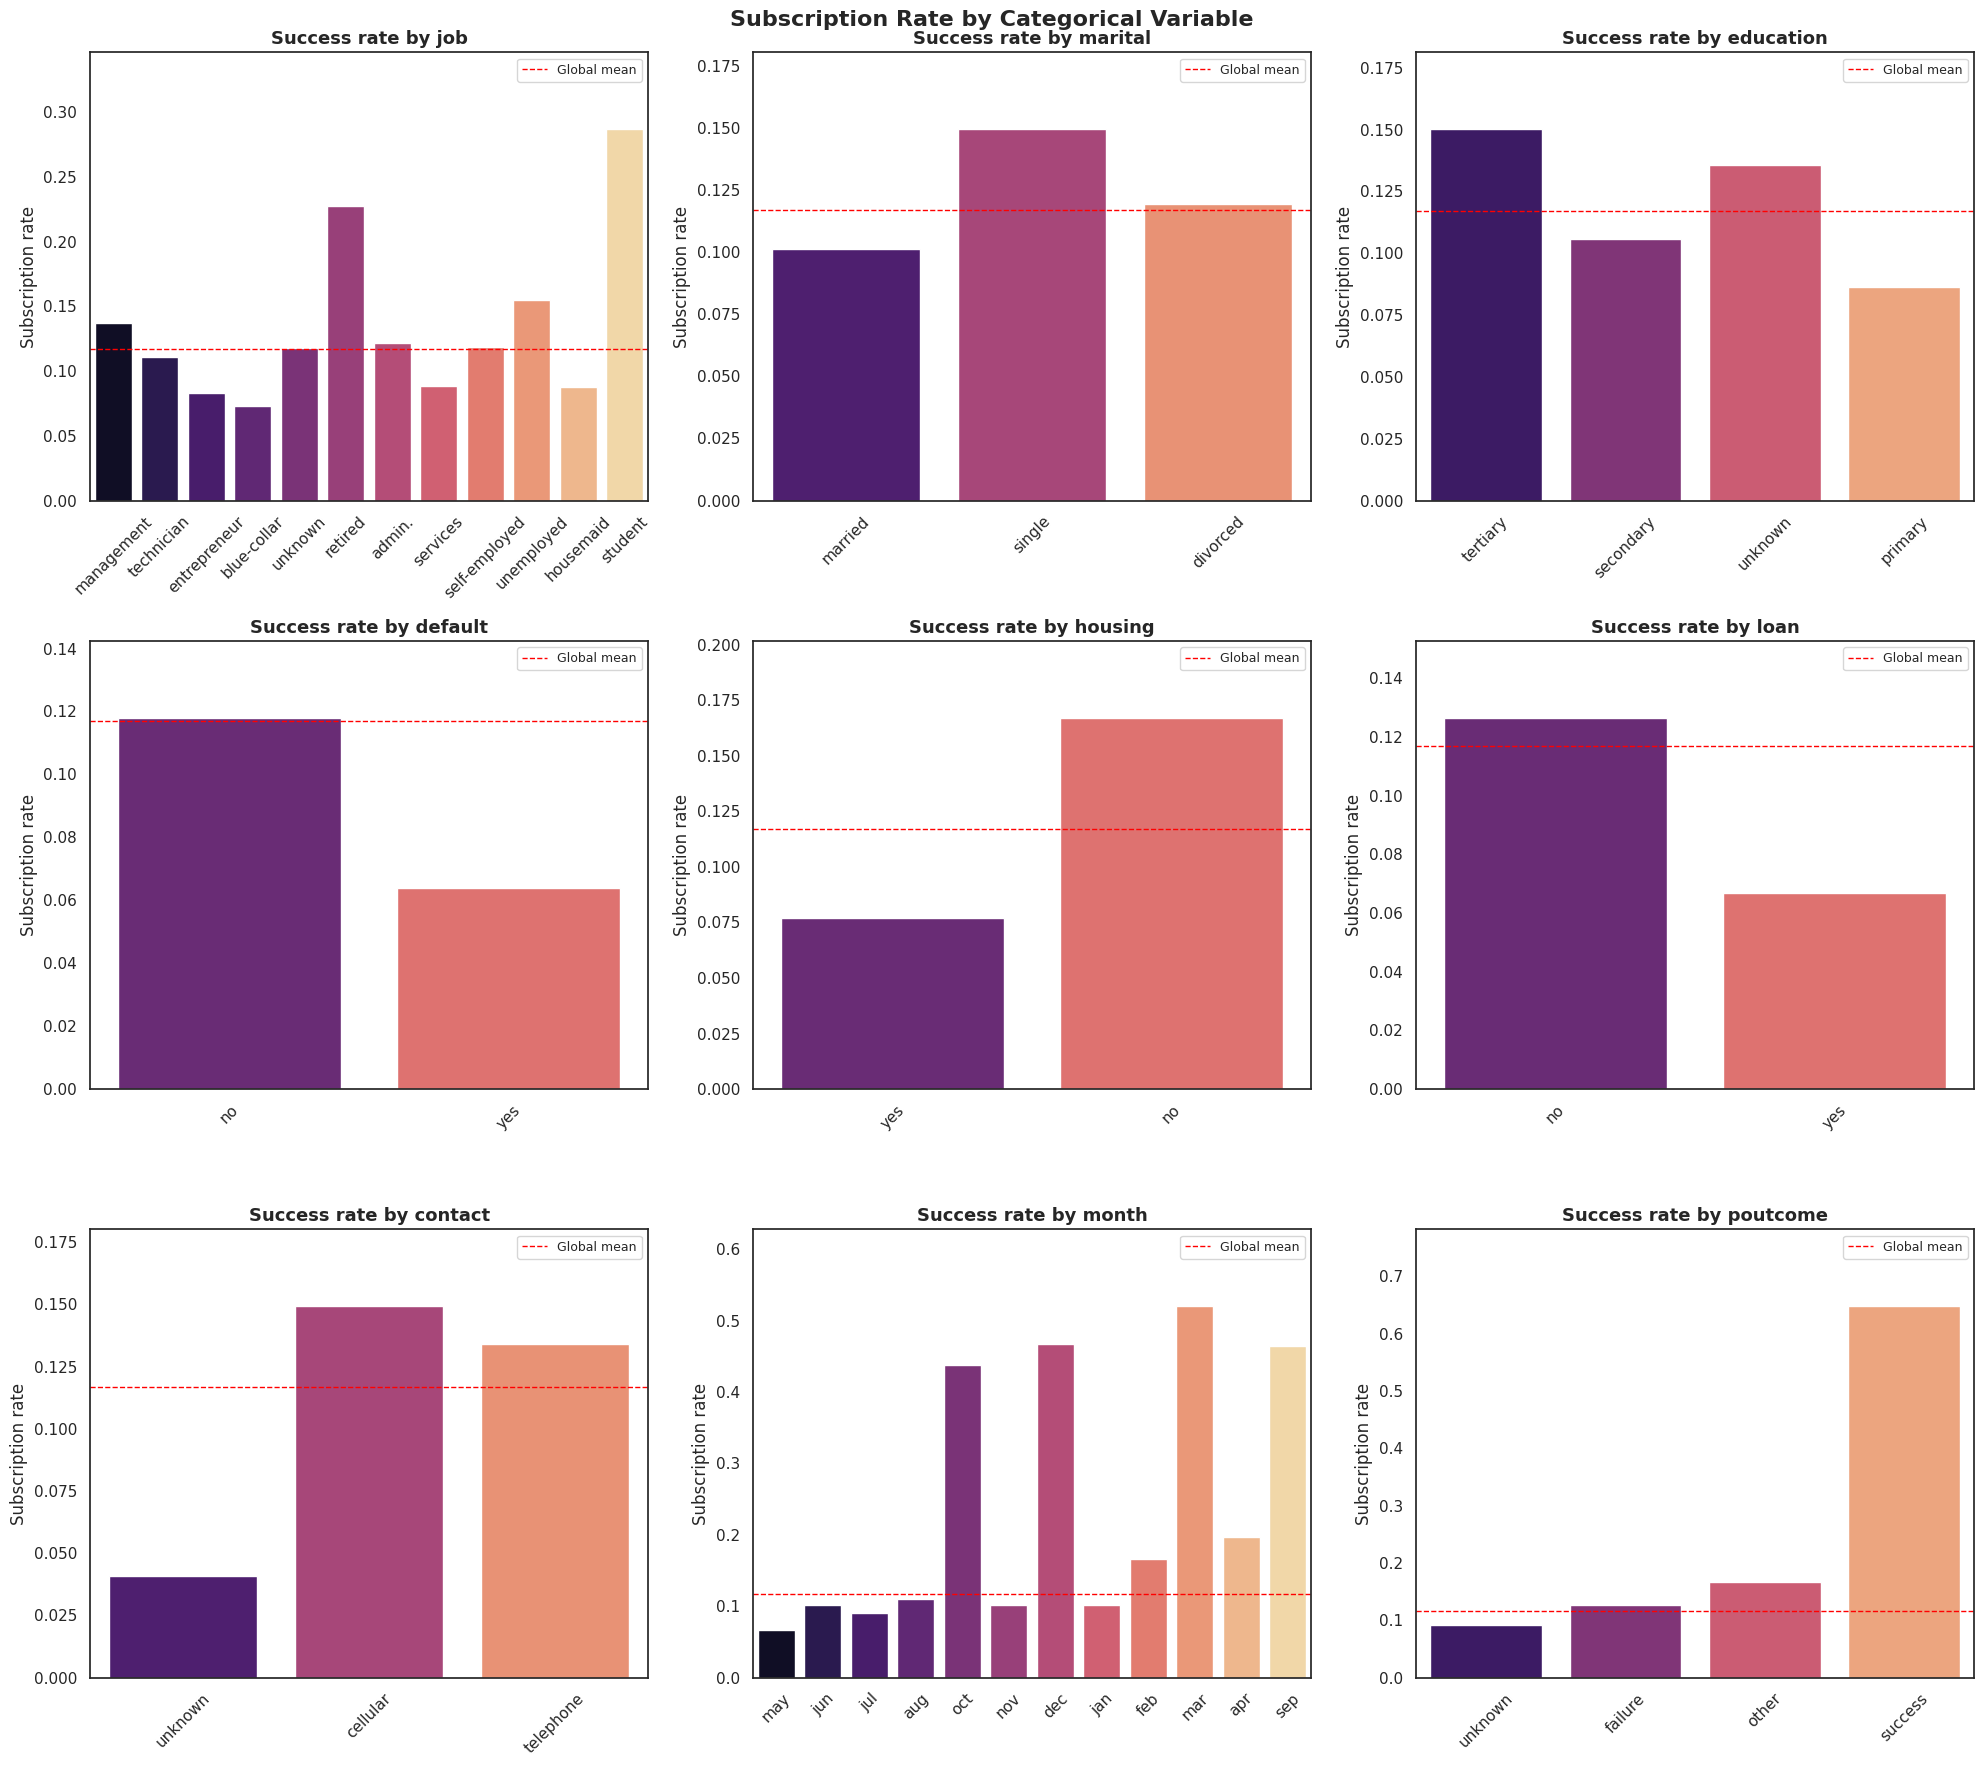

In [16]:
# Categorical variables excluding the target variable
cat_features = [col for col in bank_data.columns
                if bank_data[col].dtype == 'object' and col != 'deposit']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flat

for i, col in enumerate(cat_features):
    sns.barplot(x=col, y='deposit', data=bank_data,
                ax=axes[i], palette='magma', hue=col, legend=False,
                estimator='mean', errorbar=None)
    axes[i].set_title(f'Success rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Subscription rate')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, axes[i].get_ylim()[1] * 1.15)
    axes[i].tick_params(axis='x', rotation=45)
    # Add global mean line as reference
    axes[i].axhline(bank_data['deposit'].mean(), color='red',
                    linestyle='--', linewidth=1, label='Global mean')
    axes[i].legend(fontsize=9)

plt.suptitle('Subscription Rate by Categorical Variable', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

> **Conclusions:** The red dashed line marks the global mean (~11.7%). Notable findings:
> - **`poutcome`**: Customers with a successful previous campaign (`success`) show a much higher conversion rate (~65%). It is the strongest categorical predictor.
> - **`job`**: Students and retirees clearly exceed the global average.
> - **`month`**: March, September, October and December show the highest rates, although they have fewer calls.

### 5.3. Relationships between Numerical Variables (Pairplot)

**Use a pairplot to show the distribution and relationships of the numerical predictor variables based on the target variable.**

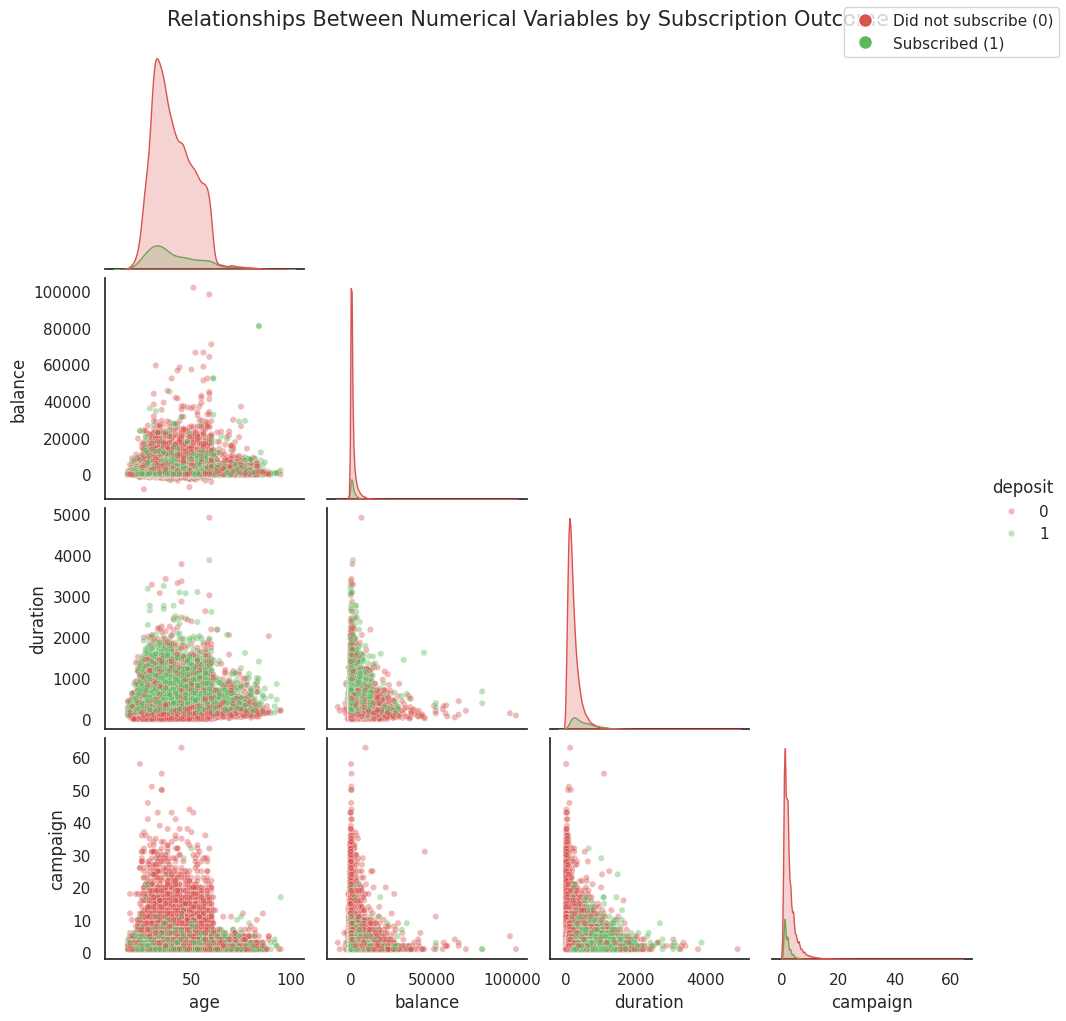

In [17]:
# Select the most representative numerical variables + the target variable
# 'day' and 'previous' are excluded as they are less visually informative
cols_of_interest = ['age', 'balance', 'duration', 'campaign', 'deposit']

g = sns.pairplot(bank_data[cols_of_interest],
                 hue='deposit',
                 palette={0: '#d9534f', 1: '#5cb85c'},
                 corner=True,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 20})

g.fig.suptitle('Relationships Between Numerical Variables by Subscription Outcome',
               fontsize=15, y=1.02)
# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#d9534f',
                           markersize=10, label='Did not subscribe (0)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#5cb85c',
                           markersize=10, label='Subscribed (1)')]
g.fig.legend(handles=legend_elements, loc='upper right', fontsize=11)
plt.show()

> **What to look for in this chart:**
> 1. **Diagonal (individual distributions):** The variable `duration` shows the greatest class separation — customers who subscribed tend to have longer calls. This variable will be removed later to prevent data leakage.
> 2. **Scatter plots:** Points of different colours are quite mixed, indicating that no single numerical variable perfectly separates the two classes.
> 3. **Outliers:** `balance` and `campaign` have extreme values that compress the bulk of the data visually.

## 6. Data Preprocessing

### 6.1. Transformation of the `month` Variable

**Transform the months into their corresponding numbers, and display the counts before and after to verify the modification was done correctly.**

In [18]:
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,  'may': 5,  'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

print("--- Count BEFORE transformation ---")
print(bank_data['month'].value_counts().sort_index().to_string())

bank_data['month'] = bank_data['month'].map(month_mapping)

print("\n--- Count AFTER transformation (sorted) ---")
print(bank_data['month'].value_counts().sort_index().to_string())
print(f"\nNew data type: {bank_data['month'].dtype}")

--- Count BEFORE transformation ---
month
apr     2932
aug     6247
dec      214
feb     2649
jan     1403
jul     6895
jun     5341
mar      477
may    13766
nov     3970
oct      738
sep      579

--- Count AFTER transformation (sorted) ---
month
1      1403
2      2649
3       477
4      2932
5     13766
6      5341
7      6895
8      6247
9       579
10      738
11     3970
12      214

New data type: int64


### 6.2. Encoding Binary Variables

**Transform the binary categorical variables `default`, `housing` and `loan` into numerical `0/1` variables. Then display them to verify the transformation is correct.**

In [19]:
binary_mapping = {'yes': 1, 'no': 0}
binary_cols = ['default', 'housing', 'loan']

for col in binary_cols:
    bank_data[col] = bank_data[col].map(binary_mapping)

# Compact verification summary
print("--- Verification of transformed binary variables ---")
print(bank_data[binary_cols].head())
print()
for col in binary_cols:
    vc = bank_data[col].value_counts()
    print(f"{col.upper():10} → 0: {vc[0]:,}  |  1: {vc[1]:,}  |  dtype: {bank_data[col].dtype}")

--- Verification of transformed binary variables ---
   default  housing  loan
0        0        1     0
1        0        1     0
2        0        1     1
3        0        1     0
4        0        0     0

DEFAULT    → 0: 44,396  |  1: 815  |  dtype: int64
HOUSING    → 0: 20,081  |  1: 25,130  |  dtype: int64
LOAN       → 0: 37,967  |  1: 7,244  |  dtype: int64


### 6.3. Exploratory Queries

**Perform 3 interesting queries on the dataset similar to the two examples above, using what you learned in the practice notebook. Another example: 'Which customers who work as technicians have subscribed to a deposit?'**

Below we perform four queries: the three requested ones plus the example proposed by the instructor.

#### 6.3.1. How many customers have NEVER been contacted?

In this dataset, `pdays = -1` means the customer was **never contacted** in previous campaigns.

In [20]:
never_contacted = (bank_data['pdays'] == -1).sum()
total = len(bank_data)
print(f"Customers never contacted: {never_contacted:,}  ({never_contacted/total:.1%} of total)")
print(f"Customers with prior contact: {total - never_contacted:,}  ({(total-never_contacted)/total:.1%} of total)")

Customers never contacted: 36,954  (81.7% of total)
Customers with prior contact: 8,257  (18.3% of total)


#### 6.3.2. How many days have passed since the oldest previous contact?

We filter customers with a prior contact history (pdays ≠ -1) and find the maximum.

In [21]:
previously_contacted = bank_data[bank_data['pdays'] != -1]
max_days = previously_contacted['pdays'].max()
print(f"Days since the oldest previous contact: {max_days} days (~{max_days/365:.1f} years)")
print()
print("Descriptive statistics of pdays for customers with prior contact history:")
print(previously_contacted['pdays'].describe().round(1).to_string())

Days since the oldest previous contact: 871 days (~2.4 years)

Descriptive statistics of pdays for customers with prior contact history:
count    8257.0
mean      224.6
std       115.3
min         1.0
25%       133.0
50%       194.0
75%       327.0
max       871.0


#### 6.3.3. Which job profiles have a conversion rate above 20%?

In [22]:
success_by_job = bank_data.groupby('job')['deposit'].mean().sort_values(ascending=False)
top_jobs = success_by_job[success_by_job > 0.20]
print("Jobs with conversion rate > 20%:")
for job, rate in top_jobs.items():
    print(f"  {job:<20} {rate:.1%}")

Jobs with conversion rate > 20%:
  student              28.7%
  retired              22.8%


#### 6.3.4. How many customers with a default history (`default=1`) subscribed to a deposit?

In [23]:
defaulters_subscribed = bank_data[(bank_data['default'] == 1) & (bank_data['deposit'] == 1)]
total_defaulters = (bank_data['default'] == 1).sum()
print(f"Customers with default who subscribed: {len(defaulters_subscribed)} out of {total_defaulters} ({len(defaulters_subscribed)/total_defaulters:.1%})")
print()
# Comparison with the global rate
print(f"Global success rate:               {bank_data['deposit'].mean():.1%}")
print(f"Success rate for customers in default: {bank_data[bank_data['default']==1]['deposit'].mean():.1%}")
print("→ Customers with a default history have a lower conversion rate than the global average.")

Customers with default who subscribed: 52 out of 815 (6.4%)

Global success rate:               11.7%
Success rate for customers in default: 6.4%
→ Customers with a default history have a lower conversion rate than the global average.


#### 6.3.5. Which customers who work as technicians have subscribed to a deposit? (instructor's example)

In [24]:
technicians_subscribed = bank_data[(bank_data['job'] == 'technician') & (bank_data['deposit'] == 1)]
total_technicians = (bank_data['job'] == 'technician').sum()
print(f"Technicians who subscribed: {len(technicians_subscribed):,} out of {total_technicians:,} ({len(technicians_subscribed)/total_technicians:.1%})")
print(f"Mean age of technicians who subscribed: {technicians_subscribed['age'].mean():.1f} years")
print(f"Mean balance of technicians who subscribed: {technicians_subscribed['balance'].mean():.0f} €")
technicians_subscribed.head()

Technicians who subscribed: 840 out of 7,597 (11.1%)
Mean age of technicians who subscribed: 39.1 years
Mean balance of technicians who subscribed: 1838 €


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
87,41,technician,married,secondary,0,1270,1,0,unknown,5,5,1389,1,-1,0,unknown,1
446,39,technician,single,unknown,0,45248,1,0,unknown,6,5,1623,1,-1,0,unknown,1
457,37,technician,married,secondary,0,1,1,0,unknown,6,5,608,1,-1,0,unknown,1
624,30,technician,married,secondary,0,484,1,0,unknown,6,5,703,1,-1,0,unknown,1
694,36,technician,married,secondary,0,368,1,1,unknown,6,5,1597,2,-1,0,unknown,1


### 6.4. Free Visualisations

**Show 2 interesting visualisations using the dataset and indicate what conclusions you draw from them.**

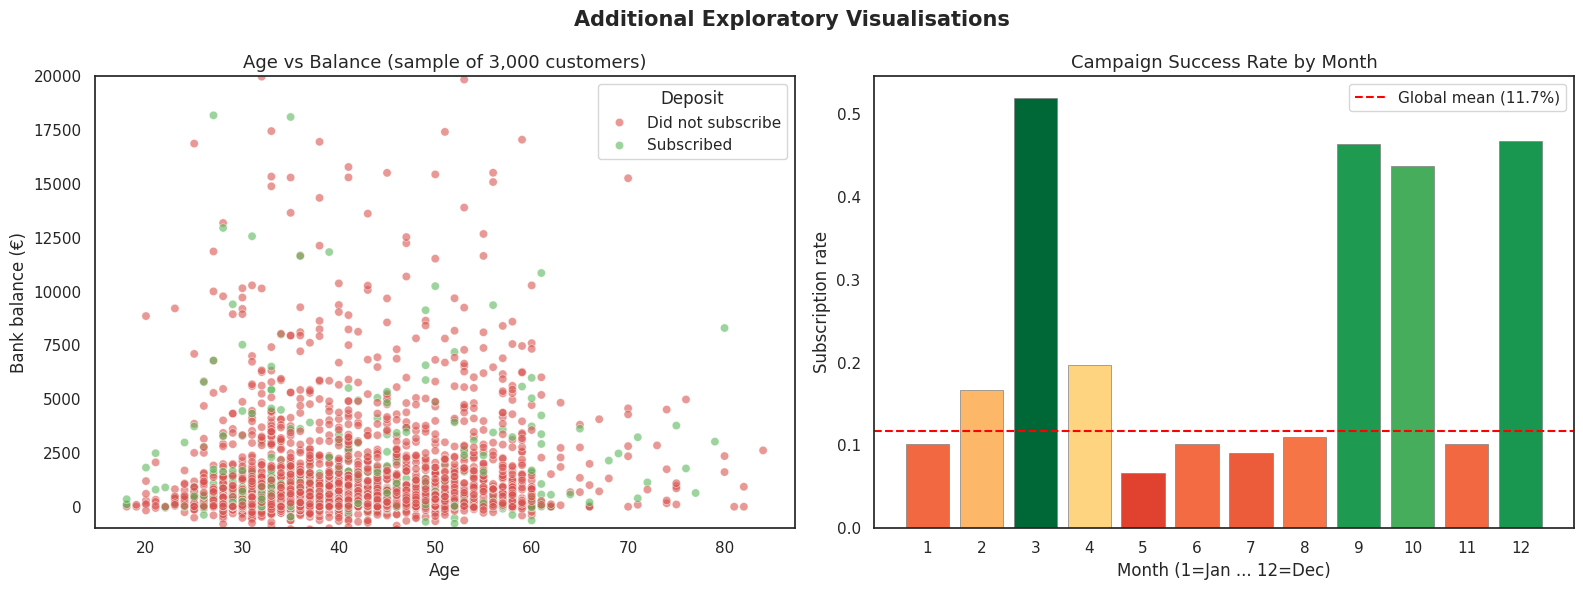

In [25]:
# ── Visualisation 1: Age vs Balance, coloured by outcome ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = bank_data.sample(3000, random_state=42)
sns.scatterplot(data=sample, x='age', y='balance', hue='deposit',
                palette={0: '#d9534f', 1: '#5cb85c'}, alpha=0.6, ax=axes[0])
axes[0].set_ylim(-1000, 20000)
axes[0].set_title('Age vs Balance (sample of 3,000 customers)', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Bank balance (€)')
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['Did not subscribe', 'Subscribed'], title='Deposit')

# ── Visualisation 2: Success rate by month ──────────────────────────────────────
monthly_success = bank_data.groupby('month')['deposit'].mean().reset_index().sort_values('month')

ax2 = axes[1]
ax2.bar(monthly_success['month'], monthly_success['deposit'],
        color=plt.cm.RdYlGn(monthly_success['deposit'] / monthly_success['deposit'].max()),
        edgecolor='gray', linewidth=0.5)
ax2.axhline(bank_data['deposit'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Global mean ({bank_data['deposit'].mean():.1%})")
ax2.set_title('Campaign Success Rate by Month', fontsize=13)
ax2.set_xlabel('Month (1=Jan ... 12=Dec)')
ax2.set_ylabel('Subscription rate')
ax2.set_xticks(range(1, 13))
ax2.legend()

plt.suptitle('Additional Exploratory Visualisations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

> **Conclusions:**
> - **Age vs Balance scatter plot:** Successful outcomes (green points) are spread throughout the entire point cloud with no clear concentration. Having a lot of money or being older does not guarantee subscription — the model will need to combine multiple variables.
> - **Monthly success rate:** The months of **March (3), September (9), October (10) and December (12)** clearly exceed the global average. Paradoxically, May — the month with the most calls — has a below-average rate. Focusing efforts on the last quarter of the year could improve campaign efficiency.

## 7. Feature Engineering on `pdays`

### 7.1. Replacement of the Sentinel Value -1

**Replace the value -1 in `pdays` with a large value (e.g. 10,000) to reflect that the customer has not been contacted for a very long time (similar to never having been contacted).**

> By replacing `-1` with `10,000`, we convert the absence code into a coherent numerical distance: customers who were never contacted are placed very far back in time, which will make sense when we compute the inverse.

In [26]:
print(f"Records with pdays = -1 before: {(bank_data['pdays'] == -1).sum():,}")

bank_data['pdays'] = bank_data['pdays'].replace(-1, 10000)

print(f"New minimum of pdays: {bank_data['pdays'].min()}")
print(f"New maximum of pdays: {bank_data['pdays'].max()}")
print(f"Records with pdays = 10000: {(bank_data['pdays'] == 10000).sum():,}")

Records with pdays = -1 before: 36,954
New minimum of pdays: 1
New maximum of pdays: 10000
Records with pdays = 10000: 36,954


### 7.2. Creation of `recent_pdays`

**Create a new column called `recent_pdays` that reflects the most recently contacted customers with the largest values, and those who have never been contacted with the smallest values (always positive). To do this, compute the inverse of the `pdays` value.**

In [27]:
# The inverse flips the scale:
#   pdays = 1     → recent_pdays = 1/1     = 1.0      (contacted yesterday → high value)
#   pdays = 100   → recent_pdays = 1/100   = 0.01
#   pdays = 10000 → recent_pdays = 1/10000 = 0.0001   (never contacted → value ~0)
bank_data['recent_pdays'] = 1 / bank_data['pdays']

print("First rows showing 'pdays' and 'recent_pdays':")
print(bank_data[['pdays', 'recent_pdays']].head(10).to_string())

First rows showing 'pdays' and 'recent_pdays':
   pdays  recent_pdays
0  10000        0.0001
1  10000        0.0001
2  10000        0.0001
3  10000        0.0001
4  10000        0.0001
5  10000        0.0001
6  10000        0.0001
7  10000        0.0001
8  10000        0.0001
9  10000        0.0001


### 7.3. Verification of `recent_pdays`

**Check the minimum and maximum values of the `recent_pdays` variable.**

In [28]:
min_recent = bank_data['recent_pdays'].min()
max_recent = bank_data['recent_pdays'].max()

print(f"Minimum value of recent_pdays: {min_recent:.6f}  → never contacted (1/10000)")
print(f"Maximum value of recent_pdays: {max_recent:.6f}  → contacted 1 day ago (1/1)")
print()
print("Descriptive statistics of recent_pdays:")
print(bank_data['recent_pdays'].describe().to_string())

Minimum value of recent_pdays: 0.000100  → never contacted (1/10000)
Maximum value of recent_pdays: 1.000000  → contacted 1 day ago (1/1)

Descriptive statistics of recent_pdays:
count    45211.000000
mean         0.002166
std          0.024128
min          0.000100
25%          0.000100
50%          0.000100
75%          0.000100
max          1.000000


### 7.4. Remove the `pdays` Column

**Since we no longer need it, drop the `pdays` column.**

In [29]:
bank_data = bank_data.drop('pdays', axis=1)

print(f"Column 'pdays' removed. Current columns: {len(bank_data.columns)}")
print(bank_data.columns.tolist())

Column 'pdays' removed. Current columns: 17
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous', 'poutcome', 'deposit', 'recent_pdays']


## 8. Additional Cleaning

### 8.1. Simplification of `poutcome`

**In the `poutcome` variable, merge `other` into `unknown`, since we do not know what `other` represents and it does not make much sense to keep them separate. Display a count of this variable to verify the result.**

In [30]:
print("--- Before ---")
print(bank_data['poutcome'].value_counts().to_string())

bank_data['poutcome'] = bank_data['poutcome'].replace('other', 'unknown')

print("\n--- After ---")
counts_poutcome = bank_data['poutcome'].value_counts()
print(counts_poutcome.to_string())
total = len(bank_data)
print(f"\n'unknown' now represents {counts_poutcome['unknown']/total:.1%} of the total.")

--- Before ---
poutcome
unknown    36959
failure     4901
other       1840
success     1511

--- After ---
poutcome
unknown    38799
failure     4901
success     1511

'unknown' now represents 85.8% of the total.


### 8.2. Removal of `contact` and `duration`

**Remove `contact` as it provides little information, and the `duration` column because the problem statement warns us that this information is not available at prediction time and would cause data leakage.**

> **Data Leakage:** `duration` (call duration) is only known *after* the call has ended, at which point the outcome `y` is already known as well. Including it would let the model learn a correlation it cannot exploit in real-world deployment. `contact` (communication type) has 28.8% `unknown` values and low predictive power.

In [31]:
cols_to_drop = ['contact', 'duration']
bank_data = bank_data.drop(columns=cols_to_drop)

print(f"Columns removed: {cols_to_drop}")
print(f"Remaining columns ({len(bank_data.columns)}): {bank_data.columns.tolist()}")

Columns removed: ['contact', 'duration']
Remaining columns (15): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'day', 'month', 'campaign', 'previous', 'poutcome', 'deposit', 'recent_pdays']


## 9. Final Encoding and Correlation Analysis

### 9.1. One-Hot Encoding

**To feed data into the k-NN algorithm, all categorical variables must be converted to numerical. We will use a method known as _one-hot encoding_, which assigns to each category a vector of `1s` and `0s` denoting the presence or absence of that feature. Use Pandas' `get_dummies()` function.**

In [32]:
cat_cols = bank_data.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

# drop_first=True removes one category per variable to avoid perfect multicollinearity
bank_data_final = pd.get_dummies(bank_data, columns=cat_cols, drop_first=True)

print(f"\nOriginal dimensions: {bank_data.shape}")
print(f"Dimensions after OHE: {bank_data_final.shape}")
print(f"\nNew columns generated: {bank_data_final.shape[1] - bank_data.shape[1] + len(cat_cols)}")
bank_data_final.head()

Categorical columns to encode: ['job', 'marital', 'education', 'poutcome']

Original dimensions: (45211, 15)
Dimensions after OHE: (45211, 29)

New columns generated: 18


,age,default,balance,housing,loan,day,month,campaign,previous,deposit,...,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,5,1,0,0,...,False,False,False,True,False,False,True,False,False,True
1,44,0,29,1,0,5,5,1,0,0,...,True,False,False,False,True,True,False,False,False,True
2,33,0,2,1,1,5,5,1,0,0,...,False,False,False,True,False,True,False,False,False,True
3,47,0,1506,1,0,5,5,1,0,0,...,False,False,False,True,False,False,False,True,False,True
4,33,0,1,0,0,5,5,1,0,0,...,False,False,True,False,True,False,False,True,False,True


### 9.2. Correlation Matrix

**Display the correlation matrix of the variables.**

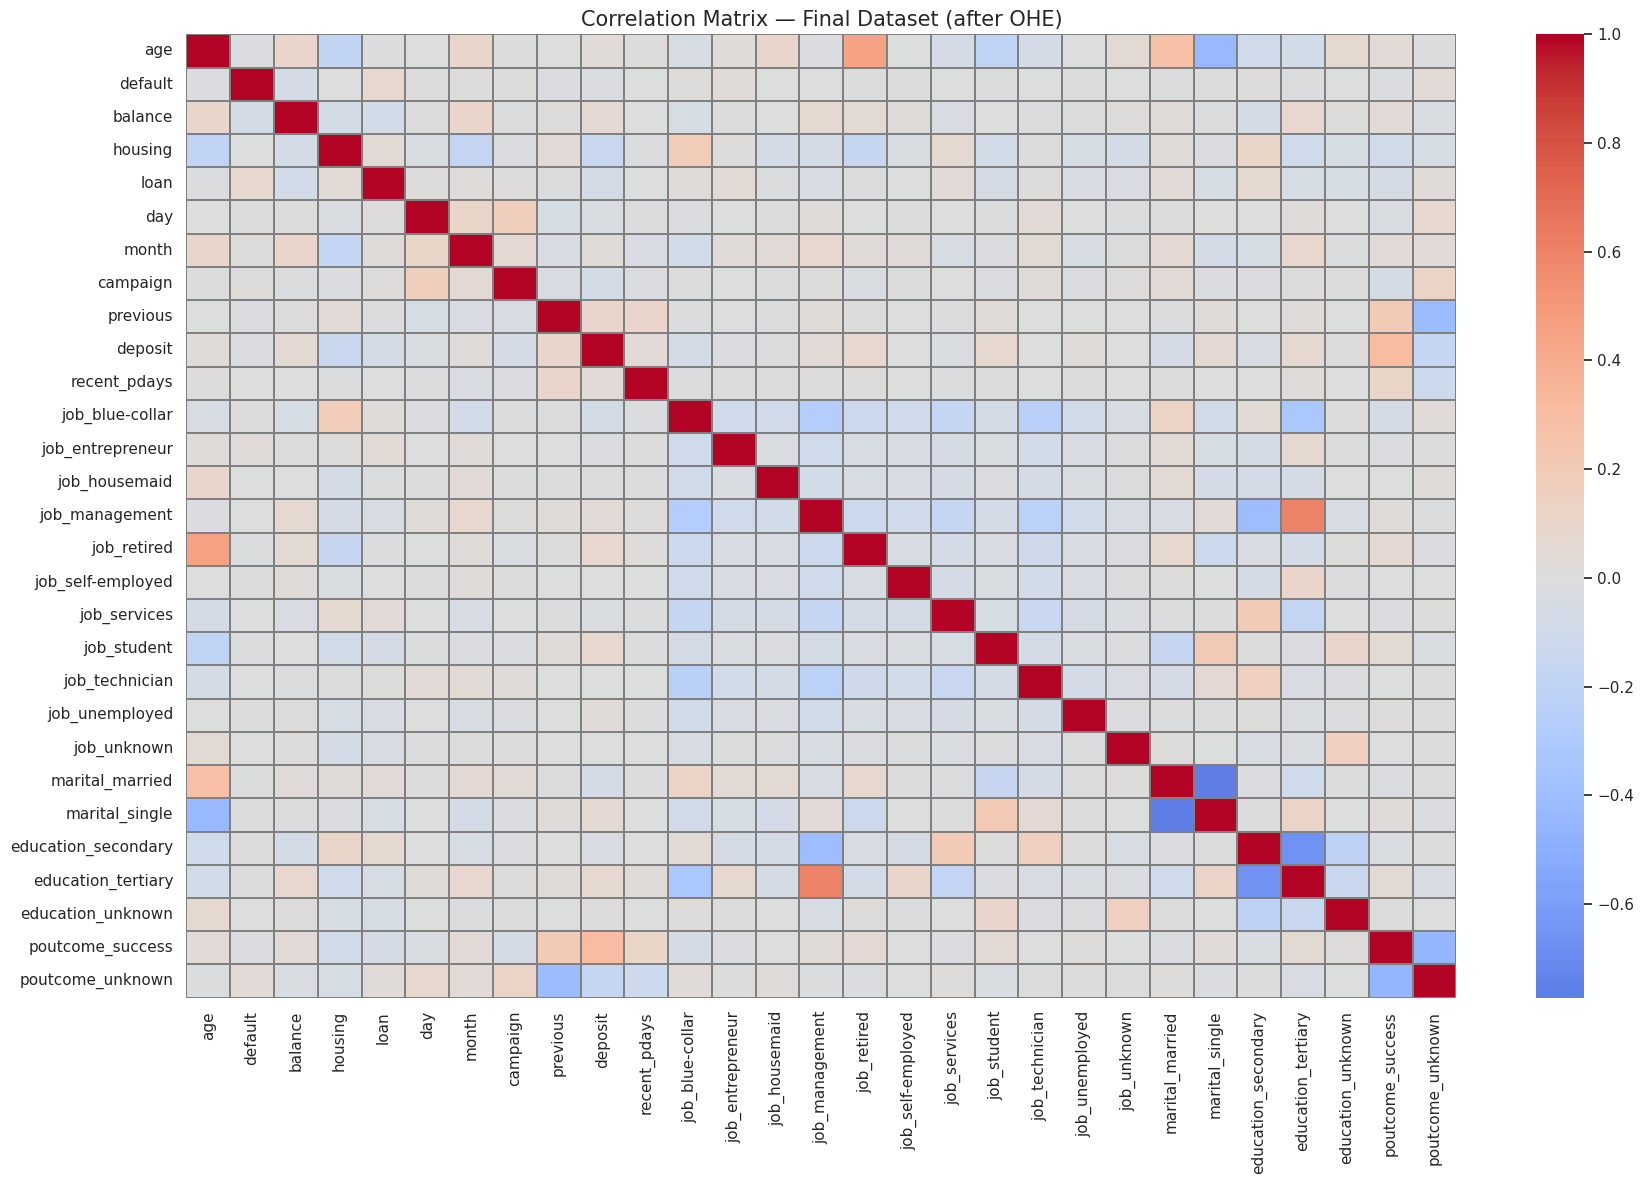

In [33]:
corr_matrix = bank_data_final.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, linecolor='gray')
plt.title('Correlation Matrix — Final Dataset (after OHE)', fontsize=15)
plt.tight_layout()
plt.show()

In [34]:
# Correlations with the target variable 'deposit'
target_corr = corr_matrix['deposit'].drop('deposit').sort_values(ascending=False)

print("Top 8 variables with POSITIVE correlation with deposit:")
print(target_corr.head(8).to_string())
print()
print("Top 8 variables with NEGATIVE correlation with deposit:")
print(target_corr.tail(8).to_string())

Top 8 variables with POSITIVE correlation with deposit:
poutcome_success      0.306788
previous              0.093236
job_retired           0.079245
job_student           0.076897
education_tertiary    0.066448
marital_single        0.063526
balance               0.052838
job_management        0.032919

Top 8 variables with NEGATIVE correlation with deposit:
day                   -0.028348
education_secondary   -0.036388
marital_married       -0.060260
loan                  -0.068185
job_blue-collar       -0.072083
campaign              -0.073172
housing               -0.139173
poutcome_unknown      -0.166863


> **Key conclusions:**
> 1. **`poutcome_success`** is by far the variable with the highest positive correlation: a previous campaign success strongly predicts a new success.
> 2. **`housing` and `poutcome_unknown`** show the highest negative correlation: having an active mortgage or no prior campaign history reduces the probability of success.
> 3. OHE-generated variables have small individual correlations, which is normal; the k-NN model combines them through its distance calculations.

## 10. Train/Test Split

### 10.1. Separation of X and y

**Separate the input variables from the target variable and assign them to two variables called `X` and `y` respectively.**

In [35]:
y = bank_data_final['deposit']
X = bank_data_final.drop('deposit', axis=1)

print(f"Dimensions of X (features): {X.shape}")
print(f"Dimensions of y (target):   {y.shape}")
print(f"\nClass proportion in y:")
print((y.value_counts(normalize=True) * 100).round(1).rename({0: 'No (0)', 1: 'Yes (1)'}).to_string())

Dimensions of X (features): (45211, 28)
Dimensions of y (target):   (45211,)

Class proportion in y:
deposit
No (0)     88.3
Yes (1)    11.7


### 10.2. 75/25 Split with Stratification

**Split the dataset into training and test sets using Scikit-Learn's `train_test_split()` function with a 75/25 ratio. What do the `random_state` and `stratify` parameters do?**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,   # Fixes the random seed for reproducibility
    stratify=y         # Preserves class proportions in both subsets
)

print(f"Training samples: {X_train.shape[0]:,}  ({X_train.shape[0]/len(X):.0%})")
print(f"Test samples:     {X_test.shape[0]:,}  ({X_test.shape[0]/len(X):.0%})")
print()
print("Proportion of positive class (deposit=1):")
print(f"  Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}  |  Global: {y.mean():.1%}")

Training samples: 33,908  (75%)
Test samples:     11,303  (25%)

Proportion of positive class (deposit=1):
  Train: 11.7%  |  Test: 11.7%  |  Global: 11.7%


> **Parameters explained:**
> - **`random_state=42`**: Fixes the random seed. It ensures that every time the code is run, the split is exactly the same, making experiments reproducible.
> - **`stratify=y`**: Ensures that the proportion of "Yes" and "No" remains equal in both train and test (~11.7% positives in each). Without this, by pure chance the test set might contain very few positive examples, making evaluation misleading.

## 11. Data Normalisation

Distance-based algorithms such as k-NN work best when the data is normalised. Normalisation rescales values to the range [0, 1].

**Normalise the training and test data using Scikit-Learn's `MinMaxScaler()`.**

In [37]:
scaler = MinMaxScaler()

# fit_transform on train: learns min and max from X_train and applies the transformation
X_train_scaled = scaler.fit_transform(X_train)

# Only transform on test: uses the parameters learned from train (avoids data leakage)
X_test_scaled  = scaler.transform(X_test)

print("Data successfully normalised.")
print(f"Range of X_train_scaled: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"Range of X_test_scaled:  [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]")

Data successfully normalised.
Range of X_train_scaled: [0.0000, 1.0000]
Range of X_test_scaled:  [0.0000, 1.0000]


> **Golden rule of scaling:** The scaler learns its parameters (minimum and maximum) **only** from the training data and then applies the same transformation to the test data. If we fitted the scaler on the test data as well, we would be leaking information from the "future" into the model — another form of *data leakage*.

## 12. Model Training (k-NN)

We will use the **k-Nearest Neighbors** model to build a classifier that predicts whether a customer will subscribe to a term deposit.

### 12.1. Search for the Optimal k

**Create a k-NN classifier and search for the number of nearest neighbours that works best. Try different values of `k`, for example between 1 and 20.**

In [38]:
k_values  = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
    print(f"k = {k:2d}: Accuracy = {acc:.4f}")

best_k = k_values[accuracies.index(max(accuracies))]
print(f"\n→ Best k found: k = {best_k}  (Accuracy = {max(accuracies):.4f})")

k =  1: Accuracy = 0.8431
k =  2: Accuracy = 0.8825
k =  3: Accuracy = 0.8745
k =  4: Accuracy = 0.8869
k =  5: Accuracy = 0.8857
k =  6: Accuracy = 0.8886
k =  7: Accuracy = 0.8874
k =  8: Accuracy = 0.8888
k =  9: Accuracy = 0.8897
k = 10: Accuracy = 0.8892
k = 11: Accuracy = 0.8904
k = 12: Accuracy = 0.8905
k = 13: Accuracy = 0.8910
k = 14: Accuracy = 0.8908
k = 15: Accuracy = 0.8914
k = 16: Accuracy = 0.8906
k = 17: Accuracy = 0.8913
k = 18: Accuracy = 0.8906
k = 19: Accuracy = 0.8905
k = 20: Accuracy = 0.8899

→ Best k found: k = 15  (Accuracy = 0.8914)


### 12.2. (Optional) Error Rate Plot as a Function of k

**(Optional) Show a graph of the evolution of the error rate as a function of the different values of k.**

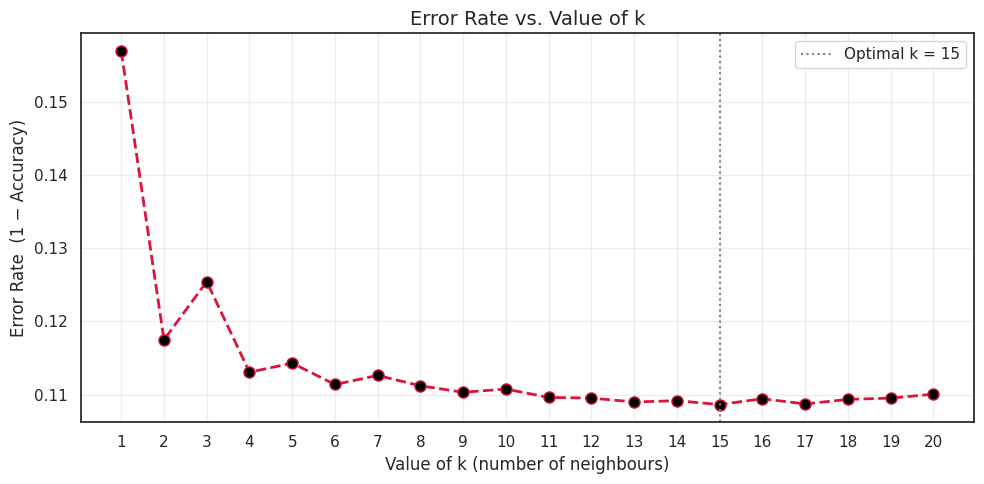

In [39]:
error_rate = [1 - acc for acc in accuracies]

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), error_rate, color='crimson', linestyle='dashed',
         marker='o', markerfacecolor='black', markersize=8, linewidth=2)
plt.axvline(best_k, color='gray', linestyle=':', linewidth=1.5,
            label=f'Optimal k = {best_k}')
plt.title('Error Rate vs. Value of k', fontsize=14)
plt.xlabel('Value of k (number of neighbours)')
plt.ylabel('Error Rate  (1 − Accuracy)')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

### 12.3. (Optional) Accuracy Plot as a Function of k

**(Optional) Show a graph of the evolution of accuracy as a function of the different values of k.**

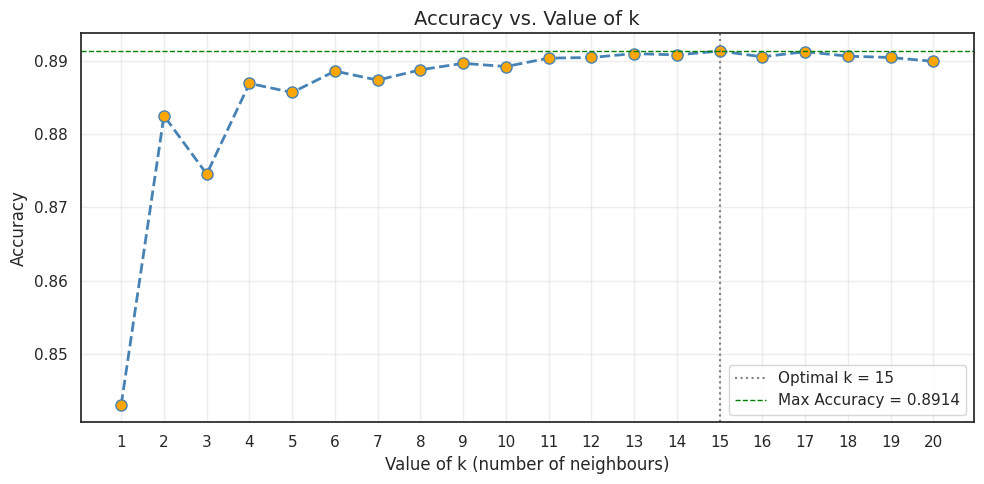

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), accuracies, color='steelblue', linestyle='dashed',
         marker='o', markerfacecolor='orange', markersize=8, linewidth=2)
plt.axvline(best_k, color='gray', linestyle=':', linewidth=1.5,
            label=f'Optimal k = {best_k}')
plt.axhline(max(accuracies), color='green', linestyle='--', linewidth=1,
            label=f'Max Accuracy = {max(accuracies):.4f}')
plt.title('Accuracy vs. Value of k', fontsize=14)
plt.xlabel('Value of k (number of neighbours)')
plt.ylabel('Accuracy')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

> **Analysis of the plots:**
> - The **error rate drops sharply** from k=1 to k≈4 (the "elbow" region), then flattens out. Beyond that, adding more neighbours brings diminishing returns.
> - **Accuracy stabilises** above 88% from k=4 onwards, with minor oscillations.
> - At k=1, the model memorises the training data (high variance); large k values over-smooth (high bias). The optimal point balances both.

### 12.4. Retraining with the Selected k

**Train the classifier again with the `k` you have selected.**

> **Selection criterion:** Even if the accuracy peak falls on an even k, we use the **nearest odd k with good performance** to avoid ties in majority voting. In binary classification, an odd k always guarantees a clear majority.

In [41]:
# Select the odd k with the best accuracy (or the optimal one if it is already odd)
best_k_odd = best_k if best_k % 2 != 0 else best_k + 1

knn_final = KNeighborsClassifier(n_neighbors=best_k_odd)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

print(f"Final model trained with k = {best_k_odd}")
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred):.4f}")

Final model trained with k = 15
Accuracy on test set: 0.8914


## 13. Making Predictions

**Make predictions for the test set.**

In [42]:
# y_pred was already computed when retraining; display it with a comparison
comparison = pd.DataFrame({'Actual Value': y_test.values, 'Prediction': y_pred})
comparison['Correct'] = (comparison['Actual Value'] == comparison['Prediction']).map({True: '✓', False: '✗'})

print("First 15 predictions vs actual values:")
print(comparison.head(15).to_string(index=False))
print()
correct = (comparison['Correct'] == '✓').sum()
print(f"Correct predictions in sample: {correct} / {len(comparison)} ({correct/len(comparison):.1%})")

First 15 predictions vs actual values:
 Actual Value  Prediction Correct
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            0           0       ✓
            1           0       ✗
            0           0       ✓
            0           0       ✓

Correct predictions in sample: 10075 / 11303 (89.1%)


## 14. Model Evaluation

### 14.1. Training and Test Scores

**Print the score for both the training and test sets of the model you just trained.**

In [43]:
train_score = knn_final.score(X_train_scaled, y_train)
test_score  = knn_final.score(X_test_scaled,  y_test)

print(f"Accuracy on training set: {train_score:.4f}")
print(f"Accuracy on test set:     {test_score:.4f}")
print(f"Difference (overfit gap): {train_score - test_score:.4f}")
print()
if train_score - test_score < 0.02:
    print("✓ Minimal gap → the model generalises well (no significant overfitting).")
else:
    print("⚠ Notable gap → possible overfitting; consider a larger k.")

Accuracy on training set: 0.8956
Accuracy on test set:     0.8914
Difference (overfit gap): 0.0043

✓ Minimal gap → the model generalises well (no significant overfitting).


### 14.2. Confusion Matrix

**Display the confusion matrix for the classifier.**

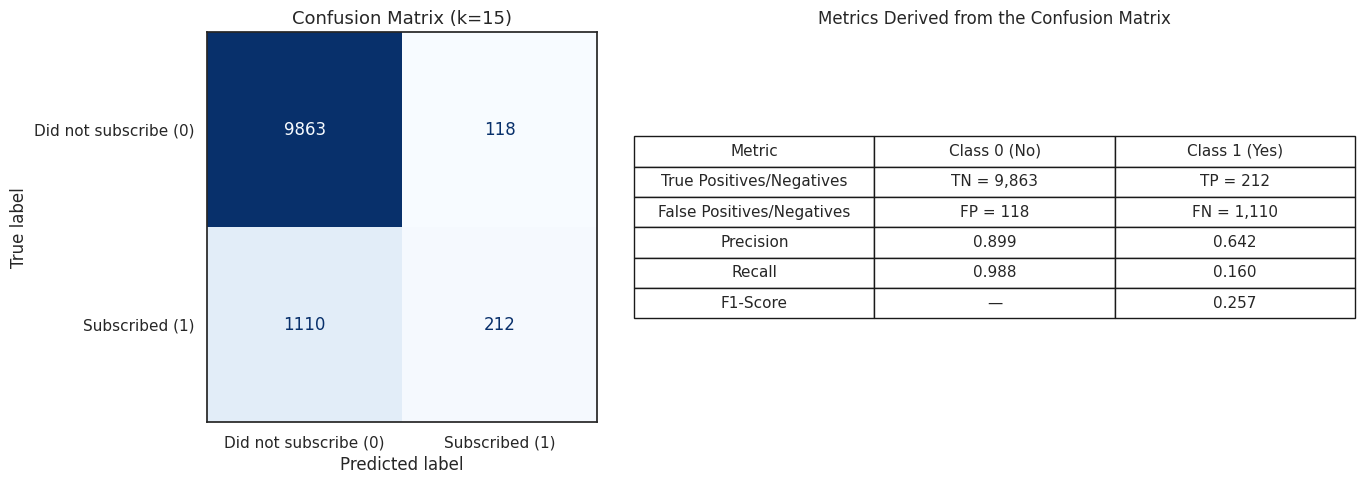


--- Summary ---
TN=9,863  FP=118
FN=1,110  TP=212


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Numerical matrix ---
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                               display_labels=['Did not subscribe (0)', 'Subscribed (1)'])
disp.plot(cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix (k={best_k_odd})', fontsize=13)

# --- Derived metrics table ---
precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_pos        = (2 * precision_pos * recall_pos /
                 (precision_pos + recall_pos)) if (precision_pos + recall_pos) > 0 else 0

axes[1].axis('off')
table_data = [
    ['Metric', 'Class 0 (No)', 'Class 1 (Yes)'],
    ['True Positives/Negatives', f'TN = {tn:,}', f'TP = {tp:,}'],
    ['False Positives/Negatives', f'FP = {fp:,}', f'FN = {fn:,}'],
    ['Precision', f'{tn/(tn+fn):.3f}', f'{precision_pos:.3f}'],
    ['Recall',    f'{tn/(tn+fp):.3f}', f'{recall_pos:.3f}'],
    ['F1-Score',  '—',                 f'{f1_pos:.3f}'],
]
t = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                  loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1.3, 1.8)
axes[1].set_title('Metrics Derived from the Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n--- Summary ---")
print(f"TN={tn:,}  FP={fp:,}")
print(f"FN={fn:,}  TP={tp:,}")

> **Interpretation:**
> - The model correctly identifies almost all **"No"** cases (high TN), which is straightforward given the class imbalance.
> - **False Negatives** (customers who would have subscribed but the model predicted "No") are the critical weakness: they represent missed sales opportunities.
> - The **low Recall of class 1** is the direct consequence of the class imbalance.

### 14.3. Classification Report

**Print the classification report. What conclusions do you draw?**

In [45]:
print(f"### Classification Report (k={best_k_odd}) ###\n")
print(classification_report(y_test, y_pred,
                             target_names=['Did not subscribe (0)', 'Subscribed (1)'],
                             digits=3))

### Classification Report (k=15) ###

                       precision    recall  f1-score   support

Did not subscribe (0)      0.899     0.988     0.941      9981
       Subscribed (1)      0.642     0.160     0.257      1322

             accuracy                          0.891     11303
            macro avg      0.771     0.574     0.599     11303
         weighted avg      0.869     0.891     0.861     11303



> **Conclusions from the report:**
> - **Class 0 (Did not subscribe):** Very high Precision and Recall (~0.90 and ~0.99). The model almost never misidentifies customers who will not subscribe.
> - **Class 1 (Subscribed):** Acceptable Precision (~0.60) but low Recall (~0.17–0.20). The model misses many true positives by being too conservative.
> - **Macro avg F1 ~ 0.60:** Reflects the true balanced performance, far below the 88% accuracy figure, which is inflated by the class imbalance.
> - **Root cause:** The original imbalance (88%/12%) leads the model to learn that "always predict No" incurs little accuracy penalty. In production, balancing techniques (SMOTE, `class_weight`) or a lower probability threshold would be advisable.

### 14.4. ROC Curve and AUC

**Finally, create a visualisation with the ROC curve and the area-under-the-curve metric.**

In [46]:
# Probabilities for the positive class
y_probs = knn_final.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)

print(f"AUC (Area Under the ROC Curve): {auc_value:.4f}")

AUC (Area Under the ROC Curve): 0.6964


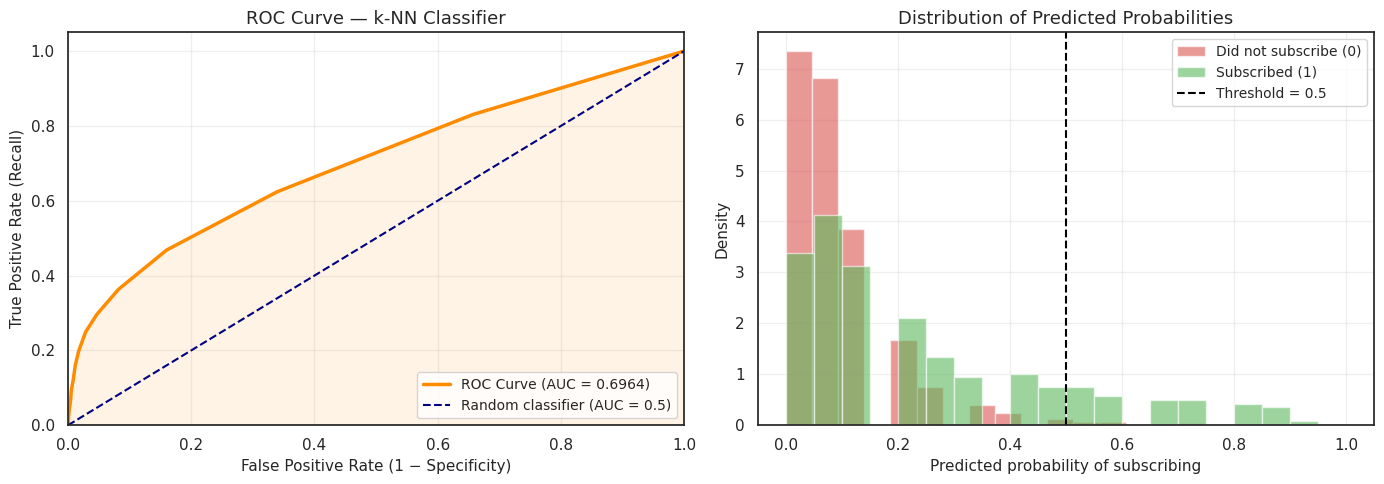

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
axes[0].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC Curve (AUC = {auc_value:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
             label='Random classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title('ROC Curve — k-NN Classifier', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# --- Distribution of predicted probabilities ---
axes[1].hist(y_probs[y_test == 0], bins=20, alpha=0.6, color='#d9534f',
             label='Did not subscribe (0)', density=True)
axes[1].hist(y_probs[y_test == 1], bins=20, alpha=0.6, color='#5cb85c',
             label='Subscribed (1)', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5,
                label='Threshold = 0.5')
axes[1].set_xlabel('Predicted probability of subscribing', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Distribution of Predicted Probabilities', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> **Interpretation of the ROC Curve and AUC:**
> - The **ROC Curve** shows the trade-off between TPR (detecting real subscribers) and FPR (false alarms) across all possible decision thresholds.
> - An **AUC around 0.70** indicates the model has genuine discriminative ability, even though the low Recall seen in the classification report results from the fixed threshold of 0.5.
> - The **probability histogram** shows why: the two classes have heavily overlapping distributions, reflecting the difficulty of the problem. Lowering the threshold to ~0.3 would increase Recall at the cost of more False Positives.
> - **Final conclusion:** The model is very efficient at ruling out uninterested customers but too conservative at identifying sales opportunities. Adjusting the threshold or applying class-balancing techniques would substantially improve its practical utility for the bank.